In [1]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

-------- (Shots = 0, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     25.8s
Evaluating N_train = 30...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     27.0s
Evaluating N_train = 50...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     29.9s
Evaluating N_train = 100...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     42.7s
Evaluating N_train = 500...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     121.5s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     361.8s
Experiment finished in 10.1 minutes.


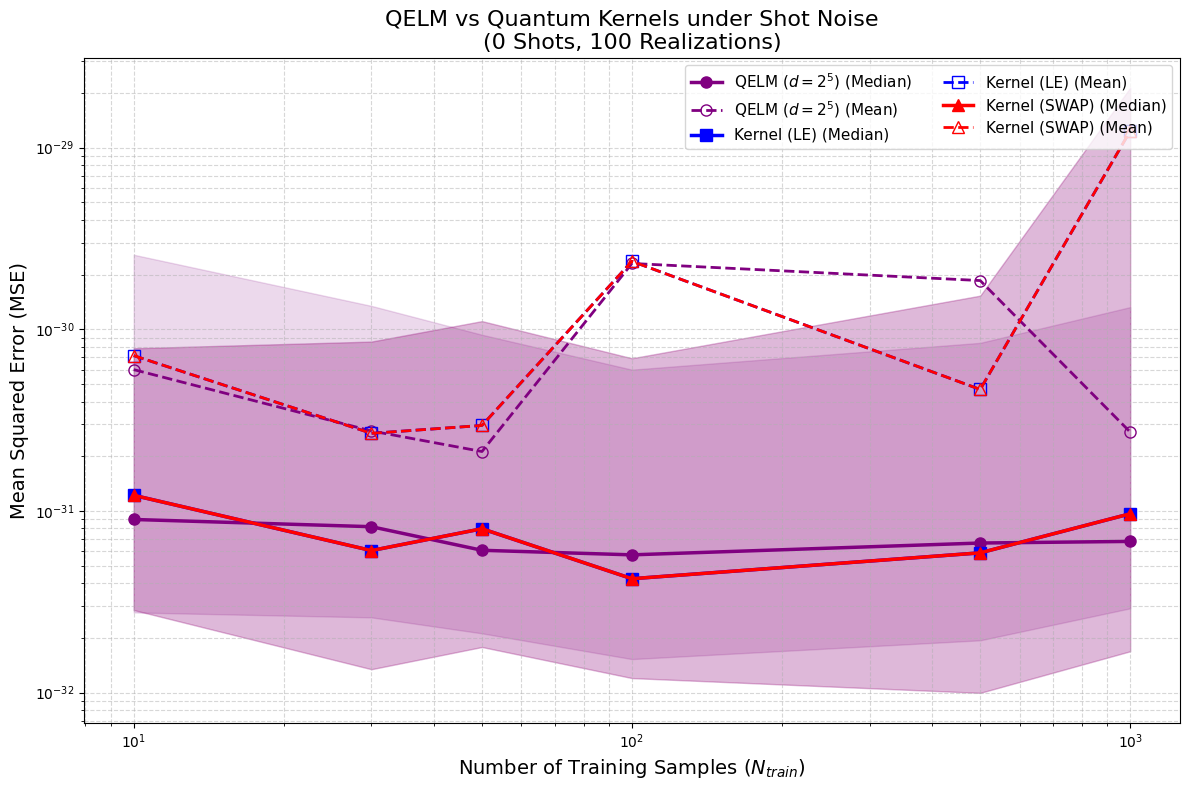

In [2]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_test = 200
num_realizations = 100
num_shots = 0

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)

# Storage dictionaries (Updated to store quantiles instead of std)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()

        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Calculate mean, median, 5th and 95th percentiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8)) # Made slightly larger to accommodate the legend
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)' if N_train == N_train_list[0] else "") 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 10000, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0015
  -> K-LE MSE: 0.0273
  -> K-SW MSE: 0.0157
  -> Time:     31.6s
Evaluating N_train = 30...
  -> QELM MSE: 0.0012
  -> K-LE MSE: 0.0943
  -> K-SW MSE: 0.0162
  -> Time:     35.8s
Evaluating N_train = 50...
  -> QELM MSE: 0.0027
  -> K-LE MSE: 0.0574
  -> K-SW MSE: 0.0613
  -> Time:     34.0s
Evaluating N_train = 100...
  -> QELM MSE: 0.0015
  -> K-LE MSE: 0.2172
  -> K-SW MSE: 0.8122
  -> Time:     57.2s
Evaluating N_train = 500...
  -> QELM MSE: 0.0006
  -> K-LE MSE: 0.2274
  -> K-SW MSE: 1.2532
  -> Time:     129.1s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0005
  -> K-LE MSE: 0.4105
  -> K-SW MSE: 5.3713
  -> Time:     394.1s
Experiment finished in 11.4 minutes.


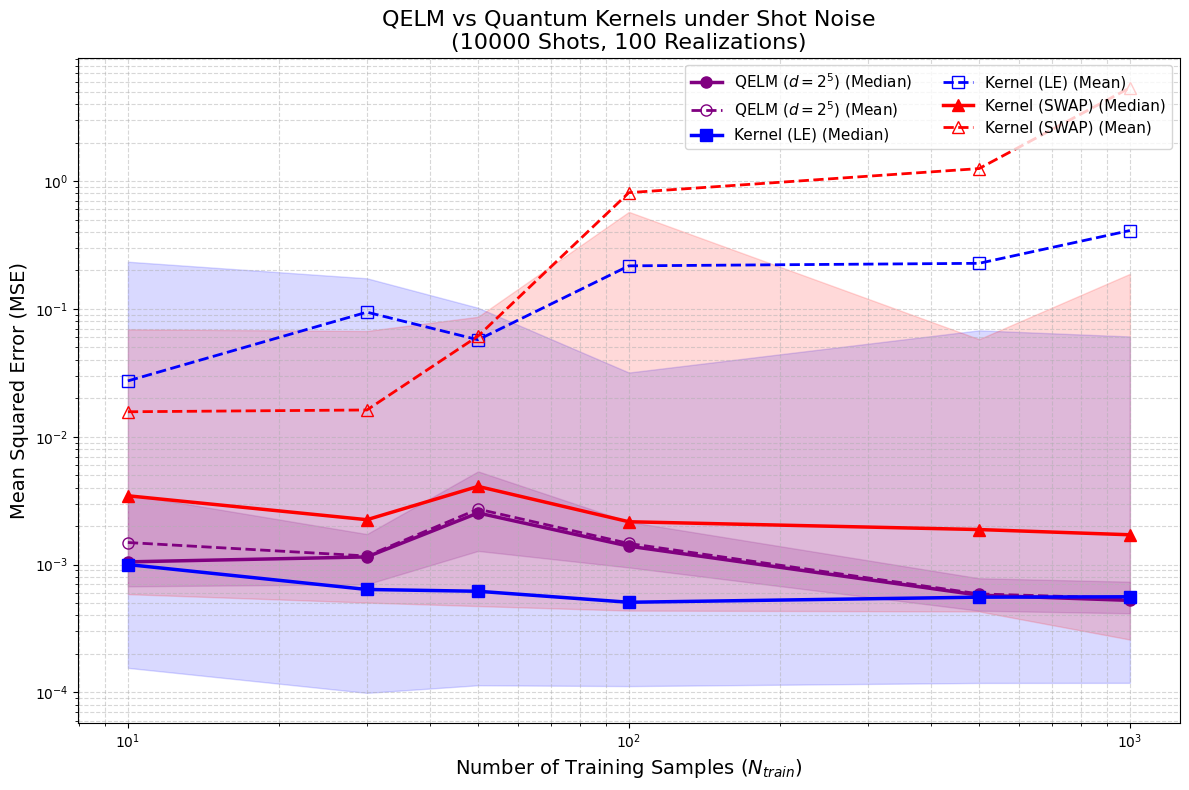

In [3]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_test = 200
num_realizations = 100
num_shots = 10000

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)

# Storage dictionaries (Updated to store quantiles instead of std)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()

        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Calculate mean, median, 5th and 95th percentiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8)) # Made slightly larger to accommodate the legend
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)' if N_train == N_train_list[0] else "") 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 1000, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0185
  -> K-LE MSE: 0.2297
  -> K-SW MSE: 7.9039
  -> Time:     37.8s
Evaluating N_train = 30...
  -> QELM MSE: 0.0112
  -> K-LE MSE: 1.1351
  -> K-SW MSE: 34.5729
  -> Time:     47.9s
Evaluating N_train = 50...
  -> QELM MSE: 0.0248
  -> K-LE MSE: 0.0380
  -> K-SW MSE: 0.8412
  -> Time:     31.7s
Evaluating N_train = 100...
  -> QELM MSE: 0.0143
  -> K-LE MSE: 10.7183
  -> K-SW MSE: 15.8865
  -> Time:     55.1s
Evaluating N_train = 500...
  -> QELM MSE: 0.0059
  -> K-LE MSE: 11.4502
  -> K-SW MSE: 0.8696
  -> Time:     146.2s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0054
  -> K-LE MSE: 0.2524
  -> K-SW MSE: 11.2502
  -> Time:     444.5s
Experiment finished in 12.7 minutes.


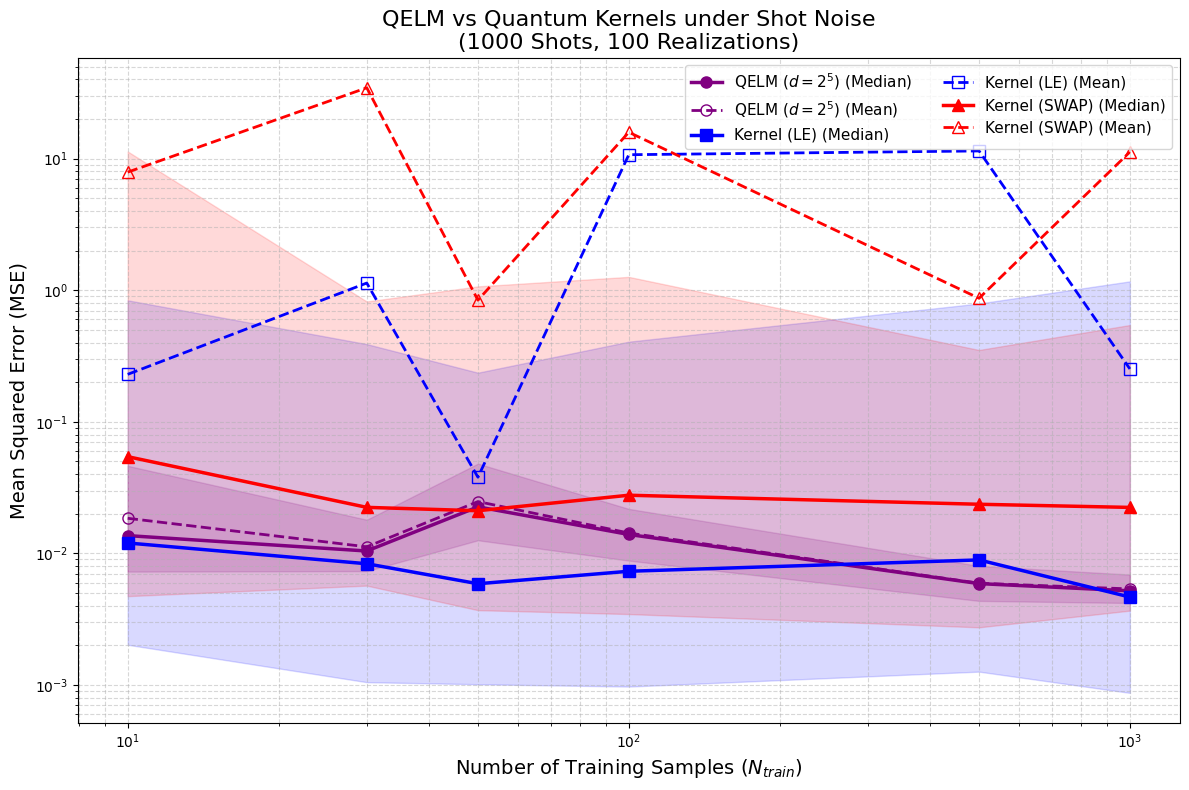

In [4]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_test = 200
num_realizations = 100
num_shots = 1000

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)

# Storage dictionaries (Updated to store quantiles instead of std)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()

        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Calculate mean, median, 5th and 95th percentiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8)) # Made slightly larger to accommodate the legend
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)' if N_train == N_train_list[0] else "") 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 100, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.1073
  -> K-LE MSE: 1.0794
  -> K-SW MSE: 1.6227
  -> Time:     34.3s
Evaluating N_train = 30...
  -> QELM MSE: 0.0923
  -> K-LE MSE: 28.6919
  -> K-SW MSE: 6.9381
  -> Time:     41.5s
Evaluating N_train = 50...
  -> QELM MSE: 0.1967
  -> K-LE MSE: 1.4473
  -> K-SW MSE: 31.4658
  -> Time:     34.5s
Evaluating N_train = 100...
  -> QELM MSE: 0.1107
  -> K-LE MSE: 3.9274
  -> K-SW MSE: 9.1833
  -> Time:     61.5s
Evaluating N_train = 500...
  -> QELM MSE: 0.0452
  -> K-LE MSE: 0.6752
  -> K-SW MSE: 0.7853
  -> Time:     164.0s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0418
  -> K-LE MSE: 27.4049
  -> K-SW MSE: 5.2164
  -> Time:     484.9s
Experiment finished in 13.7 minutes.


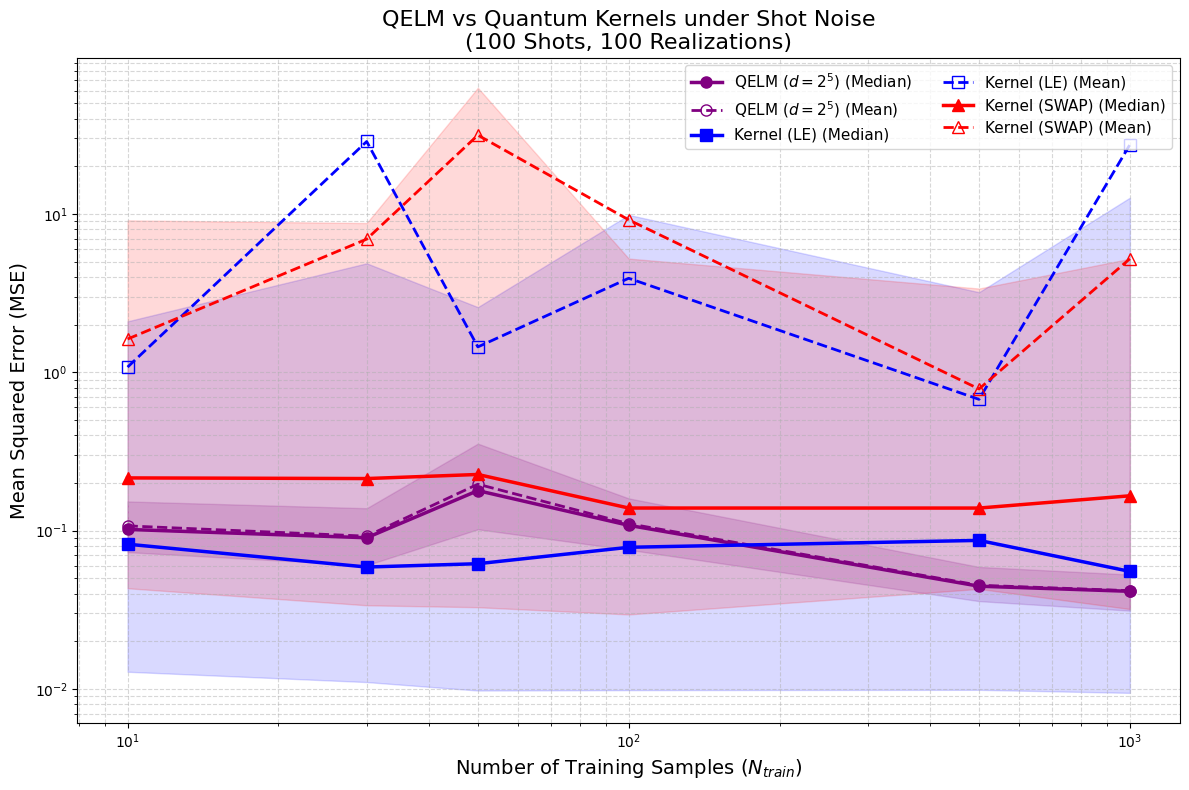

In [6]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_test = 200
num_realizations = 100
num_shots = 100

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)

# Storage dictionaries (Updated to store quantiles instead of std)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()

        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Calculate mean, median, 5th and 95th percentiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8)) # Made slightly larger to accommodate the legend
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)' if N_train == N_train_list[0] else "") 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 10, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.1875
  -> K-LE MSE: 15.1542
  -> K-SW MSE: 141.0729
  -> Time:     31.9s
Evaluating N_train = 30...
  -> QELM MSE: 0.2721
  -> K-LE MSE: 73.8543
  -> K-SW MSE: 1344.1491
  -> Time:     43.1s
Evaluating N_train = 50...
  -> QELM MSE: 0.6762
  -> K-LE MSE: 127.1412
  -> K-SW MSE: 213.7708
  -> Time:     39.8s
Evaluating N_train = 100...
  -> QELM MSE: 0.3501
  -> K-LE MSE: 37.7974
  -> K-SW MSE: 14042.7869
  -> Time:     53.2s
Evaluating N_train = 500...
  -> QELM MSE: 0.1406
  -> K-LE MSE: 260.4244
  -> K-SW MSE: 1470.0188
  -> Time:     147.2s
Evaluating N_train = 1000...
  -> QELM MSE: 0.1337
  -> K-LE MSE: 47.1384
  -> K-SW MSE: 21.3711
  -> Time:     405.5s
Experiment finished in 12.0 minutes.


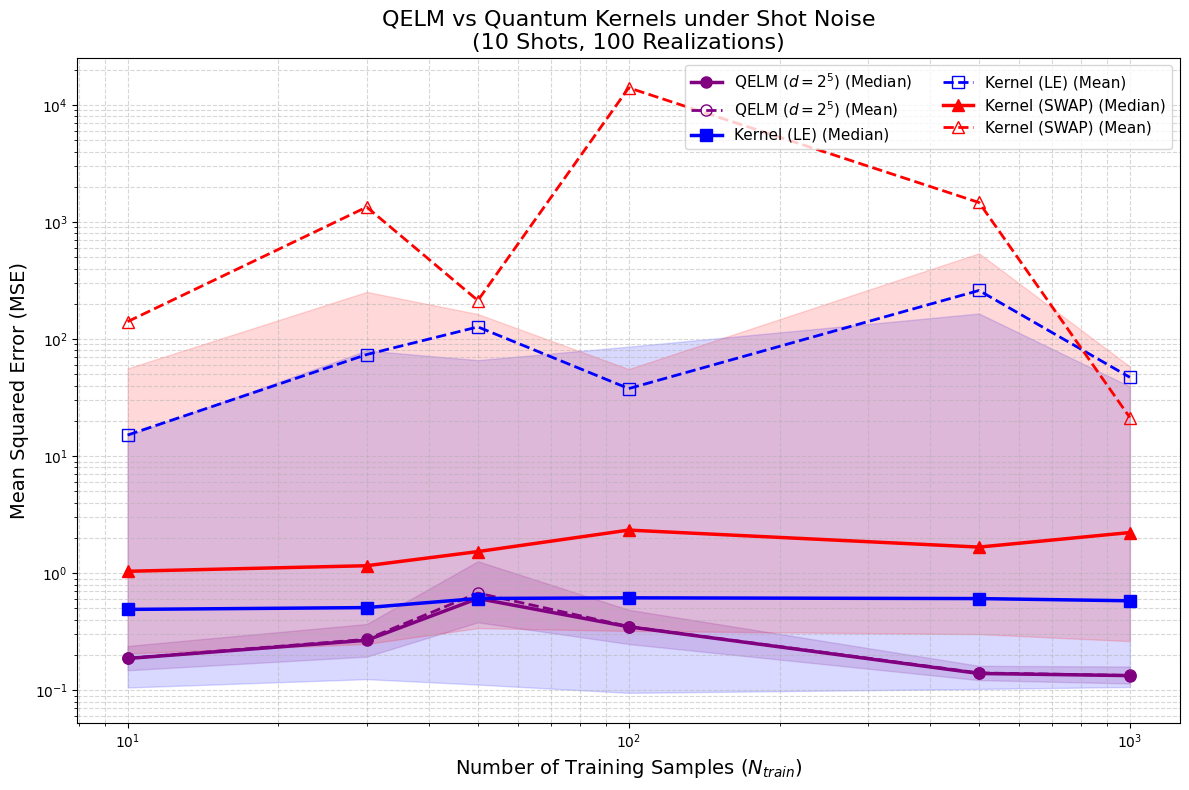

In [7]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_test = 200
num_realizations = 100
num_shots = 10

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)

# Storage dictionaries (Updated to store quantiles instead of std)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()

        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Calculate mean, median, 5th and 95th percentiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8)) # Made slightly larger to accommodate the legend
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)' if N_train == N_train_list[0] else "") 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

Generating data for N_train = 1000...
Calculating SVD for the original Kernel matrix...
Calculating pseudo-inverse for rcond = 1e-06...
Calculating pseudo-inverse for rcond = 1e-08...
Calculating pseudo-inverse for rcond = 1e-10...
Calculating pseudo-inverse for rcond = 1e-12...
Calculating pseudo-inverse for rcond = 1e-14...
Calculating pseudo-inverse for rcond = 1e-16...
Calculating pseudo-inverse for rcond = 1e-18...
Calculating pseudo-inverse for rcond = 1e-20...
Plotting results...


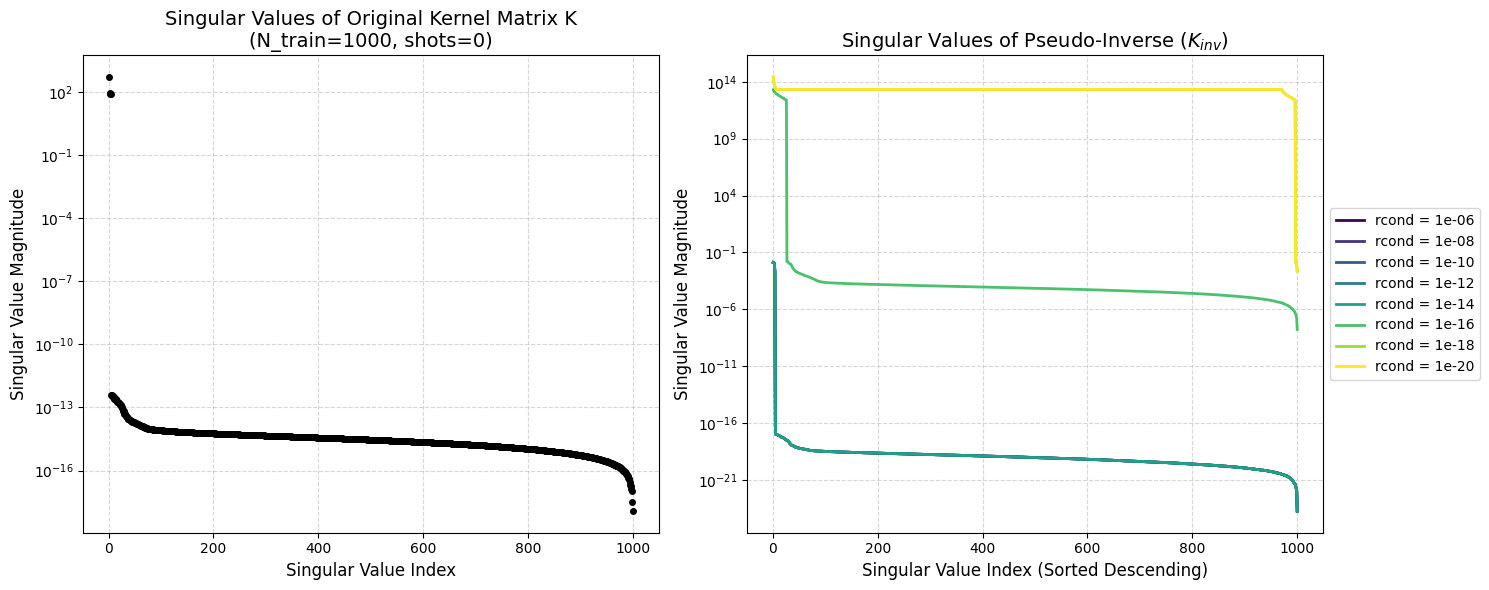

In [16]:

# --- Settings ---
N_train = 1000
N_test = 10  # We don't actually need to test for this analysis
num_shots = 0
reg_lambda = 0
rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]

print(f"Generating data for N_train = {N_train}...")

# 1. Generate a single dataset
ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
ds.generate_density_matrices_vec()
ds.compute_expectation_values_vec()  # <--- THIS LINE WAS MISSING
rho_train, y_train = ds.get_training_dataset()

# 2. Fit the Kernel Regression model just to extract the exact Kernel Matrix
# Note: For shots=0, LE and SWAP yield the exact same Kernel matrix (the exact trace)
kernel_model = myQML.QuantumKernelRegression(regularization_lambda=reg_lambda, num_shots=num_shots)
kernel_model.fit_vec(rho_train, y_train, "trace")

K = kernel_model.get_kernel_matrix()

# 3. Calculate Singular Values of the Original Kernel Matrix
# compute_uv=False saves computation time since we only want the singular values
print("Calculating SVD for the original Kernel matrix...")
s_K = np.linalg.svd(K, compute_uv=False)

# 4. Calculate Singular Values of the Pseudo-Inverse for different rcond values
s_Kinv_dict = {}

for rcond in rcond_list:
    print(f"Calculating pseudo-inverse for rcond = {rcond}...")
    # We can use numpy's pinv directly on our extracted matrix to save time
    K_inv = np.linalg.pinv(K, rcond=rcond)
    s_Kinv = np.linalg.svd(K_inv, compute_uv=False)
    s_Kinv_dict[rcond] = s_Kinv

print("Plotting results...")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Singular Values of Original Kernel Matrix
ax1.plot(range(1, len(s_K) + 1), s_K, 'k.', markersize=8)
ax1.set_yscale('log')
ax1.set_xlabel('Singular Value Index', fontsize=12)
ax1.set_ylabel('Singular Value Magnitude', fontsize=12)
ax1.set_title(f'Singular Values of Original Kernel Matrix K\n(N_train={N_train}, shots={num_shots})', fontsize=14)
ax1.grid(True, which="both", ls="--", alpha=0.5)


# Plot 2: Singular Values of the Pseudo-Inverted Kernel Matrix
colors = plt.cm.viridis(np.linspace(0, 1, len(rcond_list)))

for (rcond, s_Kinv), color in zip(s_Kinv_dict.items(), colors):
    # SVD sorts descending, so the largest inverted values (the ones causing trouble) appear first
    ax2.plot(range(1, len(s_Kinv) + 1), s_Kinv, label=f'rcond = {rcond}', color=color, linewidth=2)

ax2.set_yscale('log')
ax2.set_xlabel('Singular Value Index (Sorted Descending)', fontsize=12)
ax2.set_ylabel('Singular Value Magnitude', fontsize=12)
ax2.set_title('Singular Values of Pseudo-Inverse ($K_{inv}$)', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Generating data for N_train = 100...
Calculating SVD for the original Kernel matrix...
Calculating pseudo-inverse for rcond = 1e-06...
Calculating pseudo-inverse for rcond = 1e-08...
Calculating pseudo-inverse for rcond = 1e-10...
Calculating pseudo-inverse for rcond = 1e-12...
Calculating pseudo-inverse for rcond = 1e-14...
Calculating pseudo-inverse for rcond = 1e-16...
Calculating pseudo-inverse for rcond = 1e-18...
Calculating pseudo-inverse for rcond = 1e-20...
Plotting results...


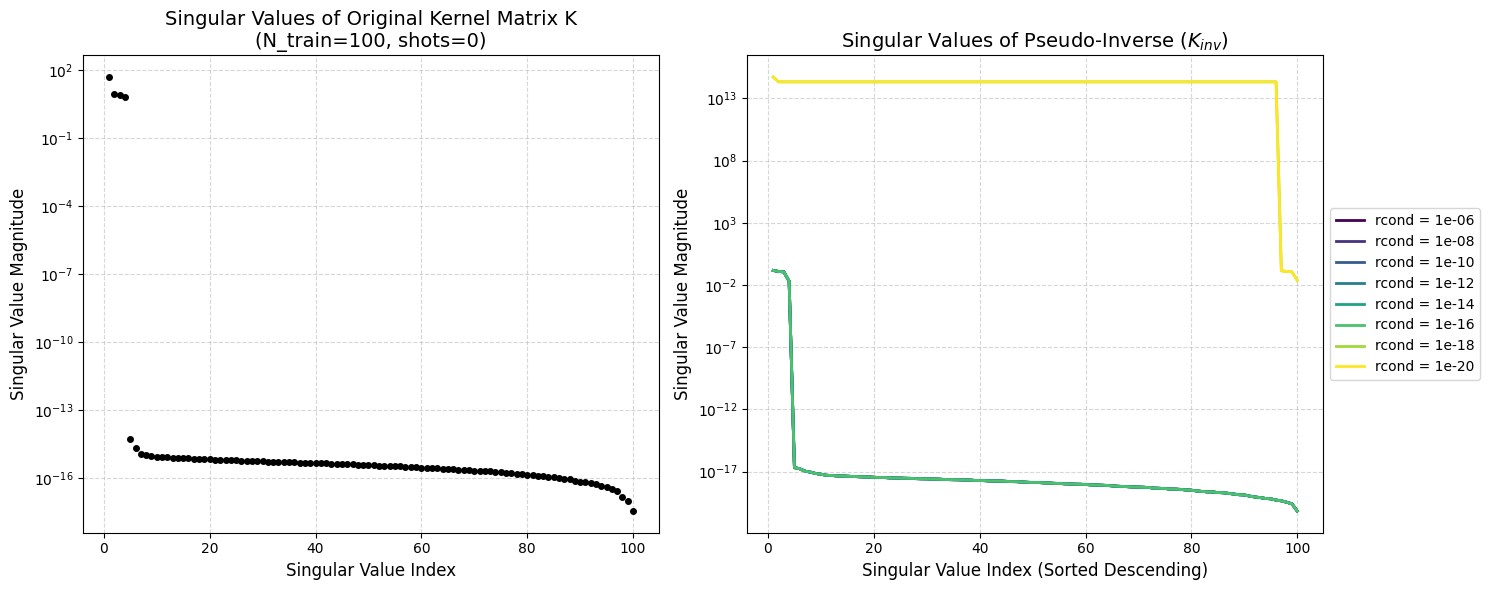

In [12]:

# --- Settings ---
N_train = 100
N_test = 10  # We don't actually need to test for this analysis
num_shots = 0
reg_lambda = 0
rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]

print(f"Generating data for N_train = {N_train}...")

# 1. Generate a single dataset
ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
ds.generate_density_matrices_vec()
ds.compute_expectation_values_vec()  # <--- THIS LINE WAS MISSING
rho_train, y_train = ds.get_training_dataset()

# 2. Fit the Kernel Regression model just to extract the exact Kernel Matrix
# Note: For shots=0, LE and SWAP yield the exact same Kernel matrix (the exact trace)
kernel_model = myQML.QuantumKernelRegression(regularization_lambda=reg_lambda, num_shots=num_shots)
kernel_model.fit_vec(rho_train, y_train, "trace")

K = kernel_model.get_kernel_matrix()

# 3. Calculate Singular Values of the Original Kernel Matrix
# compute_uv=False saves computation time since we only want the singular values
print("Calculating SVD for the original Kernel matrix...")
s_K = np.linalg.svd(K, compute_uv=False)

# 4. Calculate Singular Values of the Pseudo-Inverse for different rcond values
s_Kinv_dict = {}

for rcond in rcond_list:
    print(f"Calculating pseudo-inverse for rcond = {rcond}...")
    # We can use numpy's pinv directly on our extracted matrix to save time
    K_inv = np.linalg.pinv(K, rcond=rcond)
    s_Kinv = np.linalg.svd(K_inv, compute_uv=False)
    s_Kinv_dict[rcond] = s_Kinv

print("Plotting results...")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Singular Values of Original Kernel Matrix
ax1.plot(range(1, len(s_K) + 1), s_K, 'k.', markersize=8)
ax1.set_yscale('log')
ax1.set_xlabel('Singular Value Index', fontsize=12)
ax1.set_ylabel('Singular Value Magnitude', fontsize=12)
ax1.set_title(f'Singular Values of Original Kernel Matrix K\n(N_train={N_train}, shots={num_shots})', fontsize=14)
ax1.grid(True, which="both", ls="--", alpha=0.5)


# Plot 2: Singular Values of the Pseudo-Inverted Kernel Matrix
colors = plt.cm.viridis(np.linspace(0, 1, len(rcond_list)))

for (rcond, s_Kinv), color in zip(s_Kinv_dict.items(), colors):
    # SVD sorts descending, so the largest inverted values (the ones causing trouble) appear first
    ax2.plot(range(1, len(s_Kinv) + 1), s_Kinv, label=f'rcond = {rcond}', color=color, linewidth=2)

ax2.set_yscale('log')
ax2.set_xlabel('Singular Value Index (Sorted Descending)', fontsize=12)
ax2.set_ylabel('Singular Value Magnitude', fontsize=12)
ax2.set_title('Singular Values of Pseudo-Inverse ($K_{inv}$)', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Generating data for N_train = 1000...
Calculating SVD for the original Kernel matrix...
Calculating pseudo-inverse for rcond = 1e-06...
Calculating pseudo-inverse for rcond = 1e-08...
Calculating pseudo-inverse for rcond = 1e-10...
Calculating pseudo-inverse for rcond = 1e-12...
Calculating pseudo-inverse for rcond = 1e-14...
Calculating pseudo-inverse for rcond = 1e-15...
Calculating pseudo-inverse for rcond = 1e-16...
Calculating pseudo-inverse for rcond = 1e-18...
Calculating pseudo-inverse for rcond = 1e-20...
Plotting results...


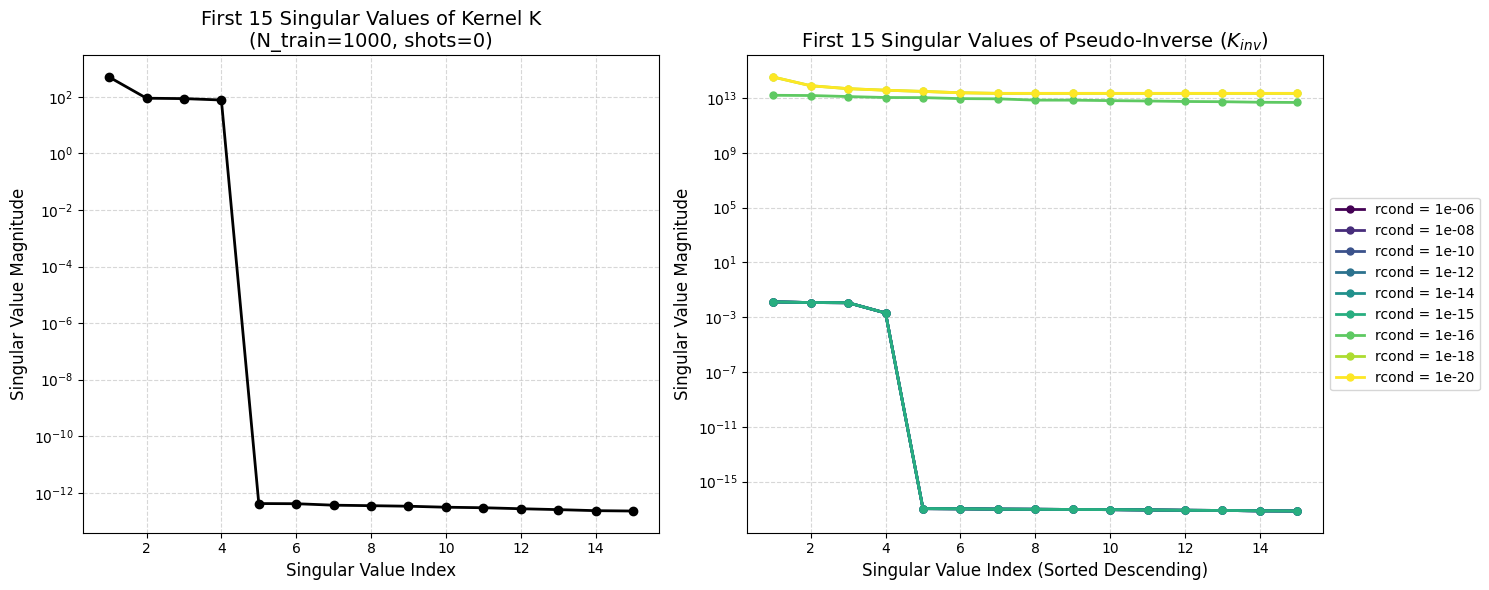

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
# import myQML 

# --- Settings ---
N_train = 1000
N_test = 10  
num_shots = 0
reg_lambda = 0
rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14,1e-15, 1e-16, 1e-18, 1e-20]

# How many singular values to plot on the x-axis
zoom_limit = 15 

print(f"Generating data for N_train = {N_train}...")

# 1. Generate a single dataset
ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
ds.generate_density_matrices_vec()
ds.compute_expectation_values_vec()  
rho_train, y_train = ds.get_training_dataset()

# 2. Fit the Kernel Regression model just to extract the exact Kernel Matrix
kernel_model = myQML.QuantumKernelRegression(regularization_lambda=reg_lambda, num_shots=num_shots)
kernel_model.fit_vec(rho_train, y_train, "trace")

K = kernel_model.get_kernel_matrix()

# 3. Calculate Singular Values of the Original Kernel Matrix
print("Calculating SVD for the original Kernel matrix...")
s_K = np.linalg.svd(K, compute_uv=False)

# 4. Calculate Singular Values of the Pseudo-Inverse for different rcond values
s_Kinv_dict = {}

for rcond in rcond_list:
    print(f"Calculating pseudo-inverse for rcond = {rcond}...")
    K_inv = np.linalg.pinv(K, rcond=rcond)
    s_Kinv = np.linalg.svd(K_inv, compute_uv=False)
    s_Kinv_dict[rcond] = s_Kinv

print("Plotting results...")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x_indices = range(1, zoom_limit + 1)

# Plot 1: Singular Values of Original Kernel Matrix (Zoomed)
ax1.plot(x_indices, s_K[:zoom_limit], 'k.-', markersize=12, linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Singular Value Index', fontsize=12)
ax1.set_ylabel('Singular Value Magnitude', fontsize=12)
ax1.set_title(f'First {zoom_limit} Singular Values of Kernel K\n(N_train={N_train}, shots={num_shots})', fontsize=14)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks



# Plot 2: Singular Values of the Pseudo-Inverted Kernel Matrix (Zoomed)
colors = plt.cm.viridis(np.linspace(0, 1, len(rcond_list)))

for (rcond, s_Kinv), color in zip(s_Kinv_dict.items(), colors):
    ax2.plot(x_indices, s_Kinv[:zoom_limit], '.-', label=f'rcond = {rcond}', 
             color=color, linewidth=2, markersize=10)

ax2.set_yscale('log')
ax2.set_xlabel('Singular Value Index (Sorted Descending)', fontsize=12)
ax2.set_ylabel('Singular Value Magnitude', fontsize=12)
ax2.set_title(f'First {zoom_limit} Singular Values of Pseudo-Inverse ($K_{{inv}}$)', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks
ax2.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Generating data for N_train = 1000...
Calculating SVD for the original Kernel matrix...
Calculating pseudo-inverse for rcond = 1e-15...
Calculating pseudo-inverse for rcond = 1e-16...
Calculating pseudo-inverse for rcond = 1e-18...
Calculating pseudo-inverse for rcond = 1e-20...
Plotting results...


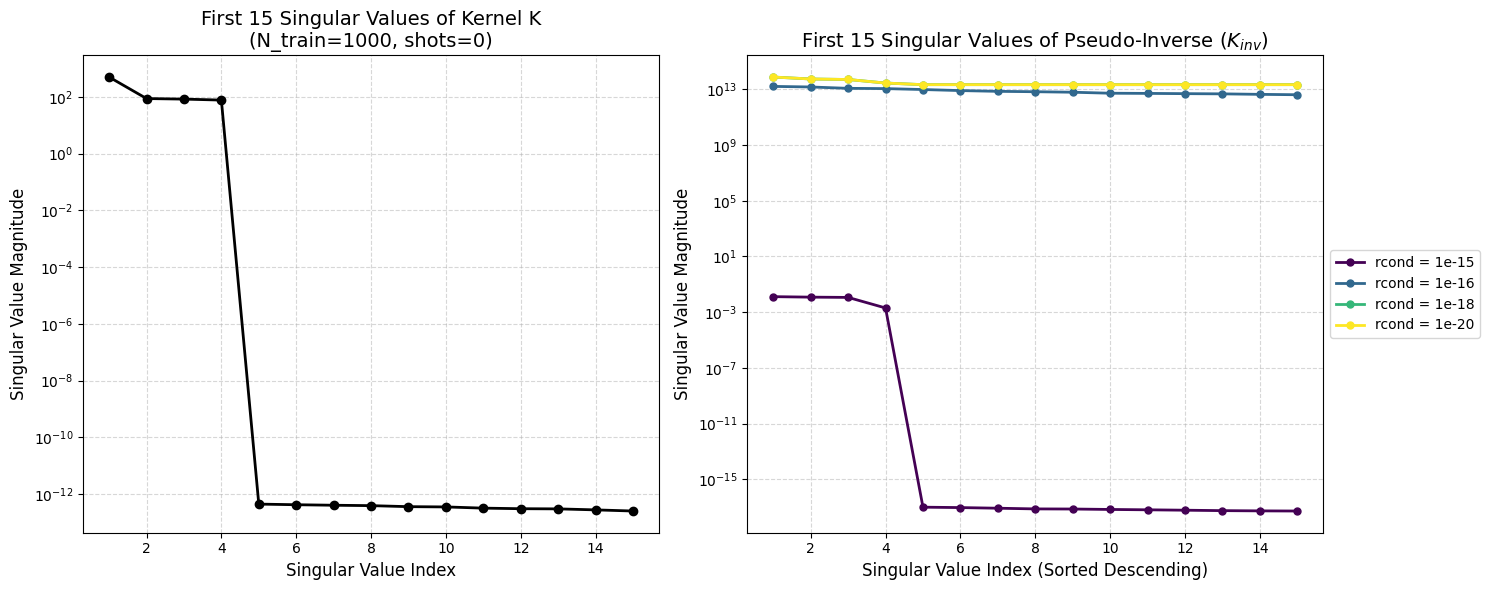

In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
# import myQML 

# --- Settings ---
N_train = 1000
N_test = 10  
num_shots = 0
reg_lambda = 0
rcond_list = [1e-15, 1e-16, 1e-18, 1e-20]

# How many singular values to plot on the x-axis
zoom_limit = 15 

print(f"Generating data for N_train = {N_train}...")

# 1. Generate a single dataset
ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
ds.generate_density_matrices_vec()
ds.compute_expectation_values_vec()  
rho_train, y_train = ds.get_training_dataset()

# 2. Fit the Kernel Regression model just to extract the exact Kernel Matrix
kernel_model = myQML.QuantumKernelRegression(regularization_lambda=reg_lambda, num_shots=num_shots)
kernel_model.fit_vec(rho_train, y_train, "trace")

K = kernel_model.get_kernel_matrix()

# 3. Calculate Singular Values of the Original Kernel Matrix
print("Calculating SVD for the original Kernel matrix...")
s_K = np.linalg.svd(K, compute_uv=False)

# 4. Calculate Singular Values of the Pseudo-Inverse for different rcond values
s_Kinv_dict = {}

for rcond in rcond_list:
    print(f"Calculating pseudo-inverse for rcond = {rcond}...")
    K_inv = np.linalg.pinv(K, rcond=rcond)
    s_Kinv = np.linalg.svd(K_inv, compute_uv=False)
    s_Kinv_dict[rcond] = s_Kinv

print("Plotting results...")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x_indices = range(1, zoom_limit + 1)

# Plot 1: Singular Values of Original Kernel Matrix (Zoomed)
ax1.plot(x_indices, s_K[:zoom_limit], 'k.-', markersize=12, linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Singular Value Index', fontsize=12)
ax1.set_ylabel('Singular Value Magnitude', fontsize=12)
ax1.set_title(f'First {zoom_limit} Singular Values of Kernel K\n(N_train={N_train}, shots={num_shots})', fontsize=14)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks



# Plot 2: Singular Values of the Pseudo-Inverted Kernel Matrix (Zoomed)
colors = plt.cm.viridis(np.linspace(0, 1, len(rcond_list)))

for (rcond, s_Kinv), color in zip(s_Kinv_dict.items(), colors):
    ax2.plot(x_indices, s_Kinv[:zoom_limit], '.-', label=f'rcond = {rcond}', 
             color=color, linewidth=2, markersize=10)

ax2.set_yscale('log')
ax2.set_xlabel('Singular Value Index (Sorted Descending)', fontsize=12)
ax2.set_ylabel('Singular Value Magnitude', fontsize=12)
ax2.set_title(f'First {zoom_limit} Singular Values of Pseudo-Inverse ($K_{{inv}}$)', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks
ax2.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Generating data for N_train = 100...
Calculating SVD for the original Kernel matrix...
Calculating pseudo-inverse for rcond = 1e-06...
Calculating pseudo-inverse for rcond = 1e-08...
Calculating pseudo-inverse for rcond = 1e-10...
Calculating pseudo-inverse for rcond = 1e-12...
Calculating pseudo-inverse for rcond = 1e-14...
Calculating pseudo-inverse for rcond = 1e-15...
Calculating pseudo-inverse for rcond = 1e-16...
Calculating pseudo-inverse for rcond = 1e-18...
Calculating pseudo-inverse for rcond = 1e-20...
Plotting results...


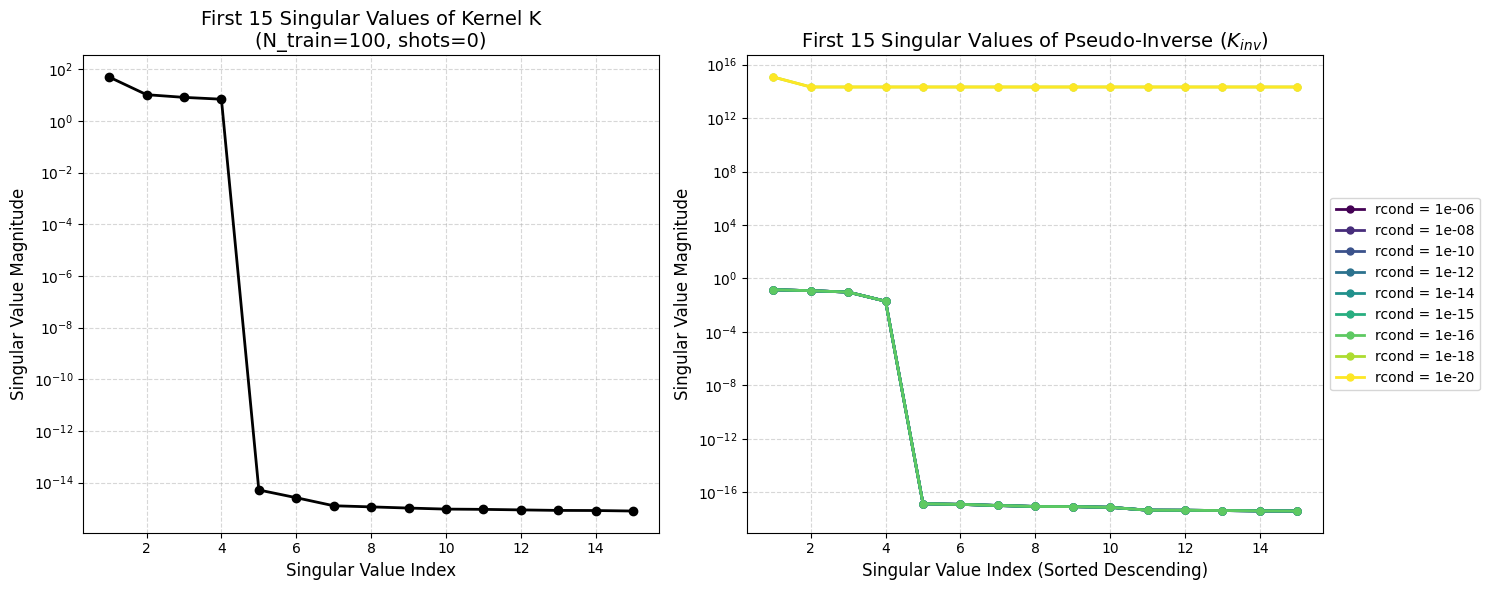

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
# import myQML 

# --- Settings ---
N_train = 100
N_test = 10  
num_shots = 0
reg_lambda = 0
rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14,1e-15, 1e-16, 1e-18, 1e-20]

# How many singular values to plot on the x-axis
zoom_limit = 15 

print(f"Generating data for N_train = {N_train}...")

# 1. Generate a single dataset
ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
ds.generate_density_matrices_vec()
ds.compute_expectation_values_vec()  
rho_train, y_train = ds.get_training_dataset()

# 2. Fit the Kernel Regression model just to extract the exact Kernel Matrix
kernel_model = myQML.QuantumKernelRegression(regularization_lambda=reg_lambda, num_shots=num_shots)
kernel_model.fit_vec(rho_train, y_train, "trace")

K = kernel_model.get_kernel_matrix()

# 3. Calculate Singular Values of the Original Kernel Matrix
print("Calculating SVD for the original Kernel matrix...")
s_K = np.linalg.svd(K, compute_uv=False)

# 4. Calculate Singular Values of the Pseudo-Inverse for different rcond values
s_Kinv_dict = {}

for rcond in rcond_list:
    print(f"Calculating pseudo-inverse for rcond = {rcond}...")
    K_inv = np.linalg.pinv(K, rcond=rcond)
    s_Kinv = np.linalg.svd(K_inv, compute_uv=False)
    s_Kinv_dict[rcond] = s_Kinv

print("Plotting results...")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x_indices = range(1, zoom_limit + 1)

# Plot 1: Singular Values of Original Kernel Matrix (Zoomed)
ax1.plot(x_indices, s_K[:zoom_limit], 'k.-', markersize=12, linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Singular Value Index', fontsize=12)
ax1.set_ylabel('Singular Value Magnitude', fontsize=12)
ax1.set_title(f'First {zoom_limit} Singular Values of Kernel K\n(N_train={N_train}, shots={num_shots})', fontsize=14)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks



# Plot 2: Singular Values of the Pseudo-Inverted Kernel Matrix (Zoomed)
colors = plt.cm.viridis(np.linspace(0, 1, len(rcond_list)))

for (rcond, s_Kinv), color in zip(s_Kinv_dict.items(), colors):
    ax2.plot(x_indices, s_Kinv[:zoom_limit], '.-', label=f'rcond = {rcond}', 
             color=color, linewidth=2, markersize=10)

ax2.set_yscale('log')
ax2.set_xlabel('Singular Value Index (Sorted Descending)', fontsize=12)
ax2.set_ylabel('Singular Value Magnitude', fontsize=12)
ax2.set_title(f'First {zoom_limit} Singular Values of Pseudo-Inverse ($K_{{inv}}$)', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks
ax2.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/610991320.py:77: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/610991320.py:79: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'Mean MSE: Interplay of $\lambda$ and rcond\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=16)


Starting 250 realizations for a N_train=100 dataset...
  -> Processed 25/250 datasets...
  -> Processed 50/250 datasets...
  -> Processed 75/250 datasets...
  -> Processed 100/250 datasets...
  -> Processed 125/250 datasets...
  -> Processed 150/250 datasets...
  -> Processed 175/250 datasets...
  -> Processed 200/250 datasets...
  -> Processed 225/250 datasets...
  -> Processed 250/250 datasets...
Computations finished in 1.0 minutes.


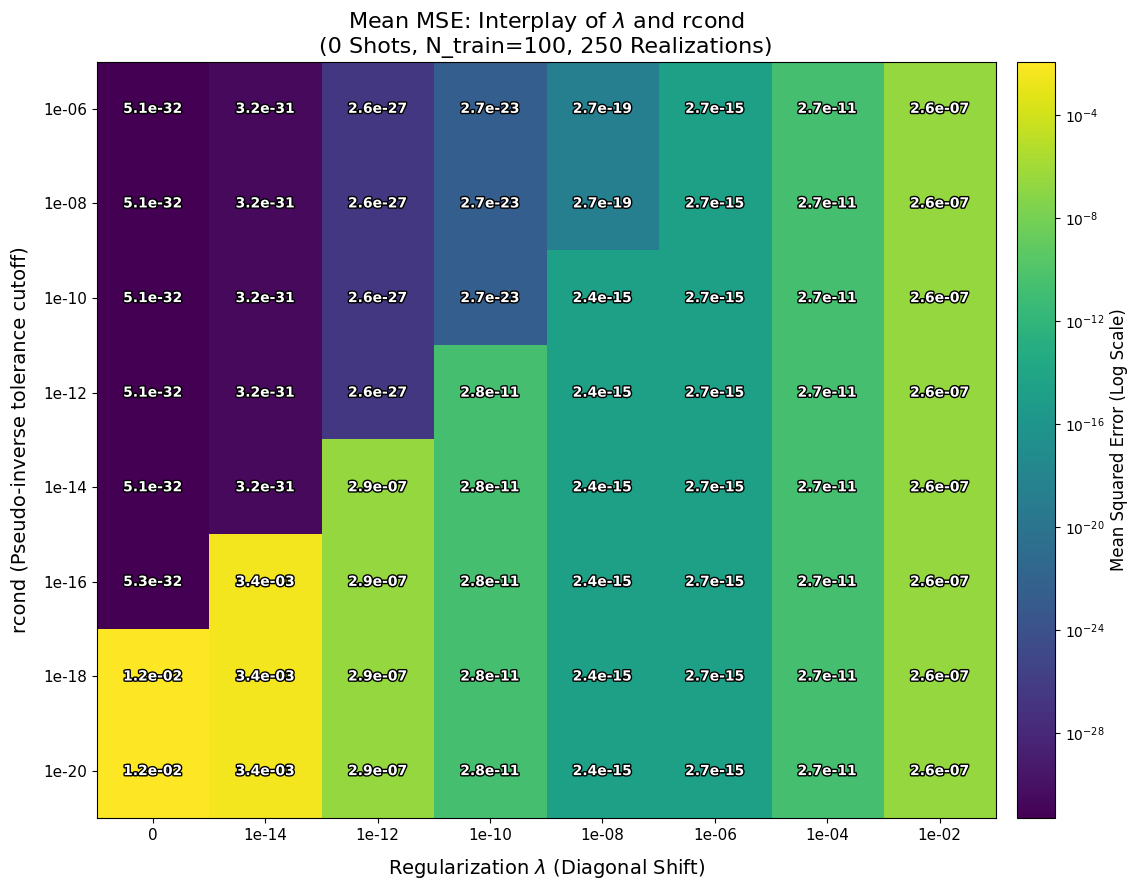

In [19]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as patheffects
# import myQML 

# --- Settings ---
N_train = 100
N_test = 200
num_realizations = 250
num_shots = 0

rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]
lambda_list = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

# Storage for the MSE values (Shape: 8 rconds x 8 lambdas x 250 realizations)
mse_grid = np.zeros((len(rcond_list), len(lambda_list), num_realizations))

print(f"Starting {num_realizations} realizations for a N_train={N_train} dataset...")
total_time = time.time()

# --- Main Evaluation Loop ---
# We loop over datasets FIRST to save massive computation time.
for r in range(num_realizations):
    if (r + 1) % 25 == 0:
        print(f"  -> Processed {r + 1}/{num_realizations} datasets...")
        
    # 1. Generate Dataset ONCE per realization
    ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()
    
    rho_train, y_train = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()
    
    # 2. Test all parameter combinations on this dataset
    for i, rcond in enumerate(rcond_list):
        for j, reg_lambda in enumerate(lambda_list):
            
            # Initialize model with specific lambda and rcond
            kernel_model = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, 
                num_shots=num_shots, 
                r_cond=rcond
            )
            
            # Fit and Predict
            kernel_model.fit_vec(rho_train, y_train, "trace")
            y_pred = kernel_model.predict_vec(rho_test)
            
            # Calculate and store MSE
            mse = np.mean((y_pred - y_test)**2)
            mse_grid[i, j, r] = mse

print(f"Computations finished in {(time.time() - total_time)/60:.1f} minutes.")

# --- Calculate Mean MSE across all realizations ---
# (You could also use np.median if outlier explosions skew the mean too much)
mean_mse_grid = np.median(mse_grid, axis=2)

# --- Plotting the Heatmap ---
fig, ax = plt.subplots(figsize=(12, 9))

# Use LogNorm because MSE can vary from 0.01 to 10^15 when matrix inversion breaks
norm = mcolors.LogNorm(vmin=np.min(mean_mse_grid), vmax=np.max(mean_mse_grid))
cax = ax.imshow(mean_mse_grid, cmap='viridis', norm=norm, aspect='auto')

# Configure axes
ax.set_xticks(np.arange(len(lambda_list)))
ax.set_yticks(np.arange(len(rcond_list)))

# Format labels cleanly (show "0" for 0, and scientific notation for others)
ax.set_xticklabels([f"{l:.0e}" if l > 0 else "0" for l in lambda_list], fontsize=11)
ax.set_yticklabels([f"{r:.0e}" for r in rcond_list], fontsize=11)

ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
ax.set_ylabel('rcond (Pseudo-inverse tolerance cutoff)', fontsize=14, labelpad=10)
ax.set_title(f'Mean MSE: Interplay of $\lambda$ and rcond\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=16)

# Annotate each cell with its MSE value
for i in range(len(rcond_list)):
    for j in range(len(lambda_list)):
        val = mean_mse_grid[i, j]
        # Text path effects adds a black outline to white text, ensuring it is always readable
        ax.text(j, i, f"{val:.1e}", ha="center", va="center", color="white", fontsize=10, fontweight='bold',
                path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

# Add colorbar
cbar = fig.colorbar(cax, ax=ax, pad=0.02)
cbar.set_label('Mean Squared Error (Log Scale)', fontsize=12)

plt.tight_layout()
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/4139213158.py:77: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/4139213158.py:79: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'Mean MSE: Interplay of $\lambda$ and rcond\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=16)


Starting 250 realizations for a N_train=200 dataset...
  -> Processed 25/250 datasets...
  -> Processed 50/250 datasets...
  -> Processed 75/250 datasets...
  -> Processed 100/250 datasets...
  -> Processed 125/250 datasets...
  -> Processed 150/250 datasets...
  -> Processed 175/250 datasets...
  -> Processed 200/250 datasets...
  -> Processed 225/250 datasets...
  -> Processed 250/250 datasets...
Computations finished in 4.3 minutes.


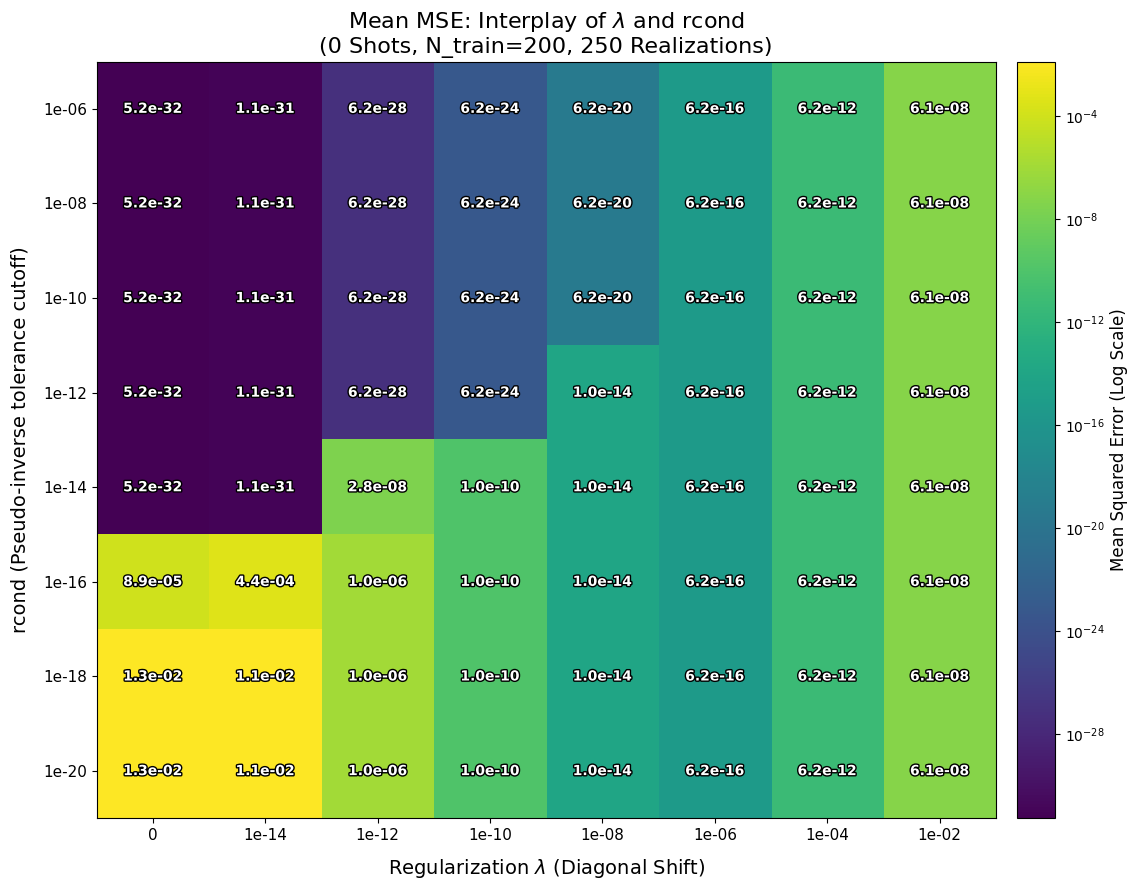

In [21]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as patheffects
# import myQML 

# --- Settings ---
N_train = 200
N_test = 200
num_realizations = 250
num_shots = 0

rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]
lambda_list = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

# Storage for the MSE values (Shape: 8 rconds x 8 lambdas x 250 realizations)
mse_grid = np.zeros((len(rcond_list), len(lambda_list), num_realizations))

print(f"Starting {num_realizations} realizations for a N_train={N_train} dataset...")
total_time = time.time()

# --- Main Evaluation Loop ---
# We loop over datasets FIRST to save massive computation time.
for r in range(num_realizations):
    if (r + 1) % 25 == 0:
        print(f"  -> Processed {r + 1}/{num_realizations} datasets...")
        
    # 1. Generate Dataset ONCE per realization
    ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()
    
    rho_train, y_train = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()
    
    # 2. Test all parameter combinations on this dataset
    for i, rcond in enumerate(rcond_list):
        for j, reg_lambda in enumerate(lambda_list):
            
            # Initialize model with specific lambda and rcond
            kernel_model = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, 
                num_shots=num_shots, 
                r_cond=rcond
            )
            
            # Fit and Predict
            kernel_model.fit_vec(rho_train, y_train, "trace")
            y_pred = kernel_model.predict_vec(rho_test)
            
            # Calculate and store MSE
            mse = np.mean((y_pred - y_test)**2)
            mse_grid[i, j, r] = mse

print(f"Computations finished in {(time.time() - total_time)/60:.1f} minutes.")

# --- Calculate Mean MSE across all realizations ---
# (You could also use np.median if outlier explosions skew the mean too much)
mean_mse_grid = np.median(mse_grid, axis=2)

# --- Plotting the Heatmap ---
fig, ax = plt.subplots(figsize=(12, 9))

# Use LogNorm because MSE can vary from 0.01 to 10^15 when matrix inversion breaks
norm = mcolors.LogNorm(vmin=np.min(mean_mse_grid), vmax=np.max(mean_mse_grid))
cax = ax.imshow(mean_mse_grid, cmap='viridis', norm=norm, aspect='auto')

# Configure axes
ax.set_xticks(np.arange(len(lambda_list)))
ax.set_yticks(np.arange(len(rcond_list)))

# Format labels cleanly (show "0" for 0, and scientific notation for others)
ax.set_xticklabels([f"{l:.0e}" if l > 0 else "0" for l in lambda_list], fontsize=11)
ax.set_yticklabels([f"{r:.0e}" for r in rcond_list], fontsize=11)

ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
ax.set_ylabel('rcond (Pseudo-inverse tolerance cutoff)', fontsize=14, labelpad=10)
ax.set_title(f'Mean MSE: Interplay of $\lambda$ and rcond\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=16)

# Annotate each cell with its MSE value
for i in range(len(rcond_list)):
    for j in range(len(lambda_list)):
        val = mean_mse_grid[i, j]
        # Text path effects adds a black outline to white text, ensuring it is always readable
        ax.text(j, i, f"{val:.1e}", ha="center", va="center", color="white", fontsize=10, fontweight='bold',
                path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

# Add colorbar
cbar = fig.colorbar(cax, ax=ax, pad=0.02)
cbar.set_label('Mean Squared Error (Log Scale)', fontsize=12)

plt.tight_layout()
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/2150346480.py:77: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/2150346480.py:79: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'Mean MSE: Interplay of $\lambda$ and rcond\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=16)


Starting 250 realizations for a N_train=300 dataset...
  -> Processed 25/250 datasets...
  -> Processed 50/250 datasets...
  -> Processed 75/250 datasets...
  -> Processed 100/250 datasets...
  -> Processed 125/250 datasets...
  -> Processed 150/250 datasets...
  -> Processed 175/250 datasets...
  -> Processed 200/250 datasets...
  -> Processed 225/250 datasets...
  -> Processed 250/250 datasets...
Computations finished in 11.7 minutes.


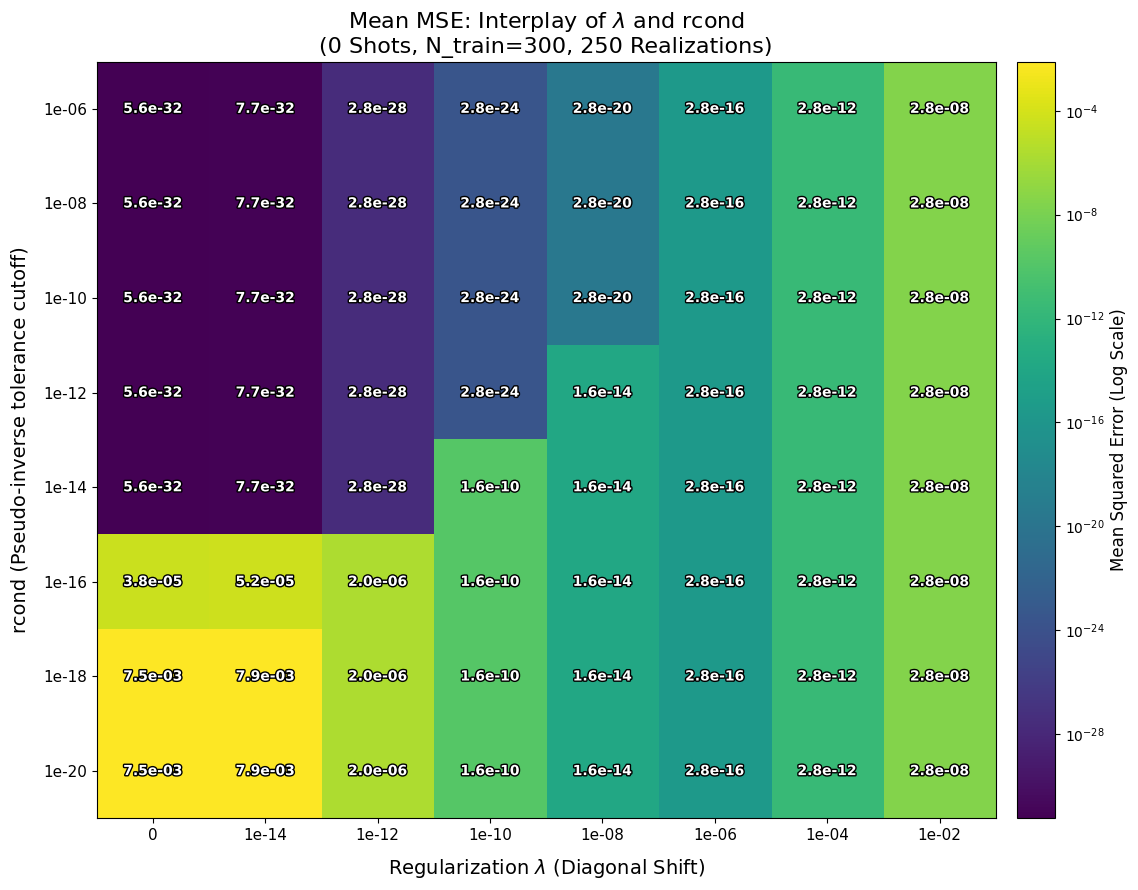

In [22]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as patheffects
# import myQML 

# --- Settings ---
N_train = 300
N_test = 200
num_realizations = 250
num_shots = 0

rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]
lambda_list = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

# Storage for the MSE values (Shape: 8 rconds x 8 lambdas x 250 realizations)
mse_grid = np.zeros((len(rcond_list), len(lambda_list), num_realizations))

print(f"Starting {num_realizations} realizations for a N_train={N_train} dataset...")
total_time = time.time()

# --- Main Evaluation Loop ---
# We loop over datasets FIRST to save massive computation time.
for r in range(num_realizations):
    if (r + 1) % 25 == 0:
        print(f"  -> Processed {r + 1}/{num_realizations} datasets...")
        
    # 1. Generate Dataset ONCE per realization
    ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()
    
    rho_train, y_train = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()
    
    # 2. Test all parameter combinations on this dataset
    for i, rcond in enumerate(rcond_list):
        for j, reg_lambda in enumerate(lambda_list):
            
            # Initialize model with specific lambda and rcond
            kernel_model = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, 
                num_shots=num_shots, 
                r_cond=rcond
            )
            
            # Fit and Predict
            kernel_model.fit_vec(rho_train, y_train, "trace")
            y_pred = kernel_model.predict_vec(rho_test)
            
            # Calculate and store MSE
            mse = np.mean((y_pred - y_test)**2)
            mse_grid[i, j, r] = mse

print(f"Computations finished in {(time.time() - total_time)/60:.1f} minutes.")

# --- Calculate Mean MSE across all realizations ---
# (You could also use np.median if outlier explosions skew the mean too much)
mean_mse_grid = np.median(mse_grid, axis=2)

# --- Plotting the Heatmap ---
fig, ax = plt.subplots(figsize=(12, 9))

# Use LogNorm because MSE can vary from 0.01 to 10^15 when matrix inversion breaks
norm = mcolors.LogNorm(vmin=np.min(mean_mse_grid), vmax=np.max(mean_mse_grid))
cax = ax.imshow(mean_mse_grid, cmap='viridis', norm=norm, aspect='auto')

# Configure axes
ax.set_xticks(np.arange(len(lambda_list)))
ax.set_yticks(np.arange(len(rcond_list)))

# Format labels cleanly (show "0" for 0, and scientific notation for others)
ax.set_xticklabels([f"{l:.0e}" if l > 0 else "0" for l in lambda_list], fontsize=11)
ax.set_yticklabels([f"{r:.0e}" for r in rcond_list], fontsize=11)

ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
ax.set_ylabel('rcond (Pseudo-inverse tolerance cutoff)', fontsize=14, labelpad=10)
ax.set_title(f'Mean MSE: Interplay of $\lambda$ and rcond\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=16)

# Annotate each cell with its MSE value
for i in range(len(rcond_list)):
    for j in range(len(lambda_list)):
        val = mean_mse_grid[i, j]
        # Text path effects adds a black outline to white text, ensuring it is always readable
        ax.text(j, i, f"{val:.1e}", ha="center", va="center", color="white", fontsize=10, fontweight='bold',
                path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

# Add colorbar
cbar = fig.colorbar(cax, ax=ax, pad=0.02)
cbar.set_label('Mean Squared Error (Log Scale)', fontsize=12)

plt.tight_layout()
plt.show()

<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/2469661104.py:85: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/2469661104.py:105: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Interplay of $\lambda$ and rcond under Finite Shot Noise\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=18, y=1.02)


Starting 250 realizations (N_train=100, shots=1000)...
  -> Processed 25/250 datasets...
  -> Processed 50/250 datasets...
  -> Processed 75/250 datasets...
  -> Processed 100/250 datasets...
  -> Processed 125/250 datasets...
  -> Processed 150/250 datasets...
  -> Processed 175/250 datasets...
  -> Processed 200/250 datasets...
  -> Processed 225/250 datasets...
  -> Processed 250/250 datasets...
Computations finished in 5.0 minutes.


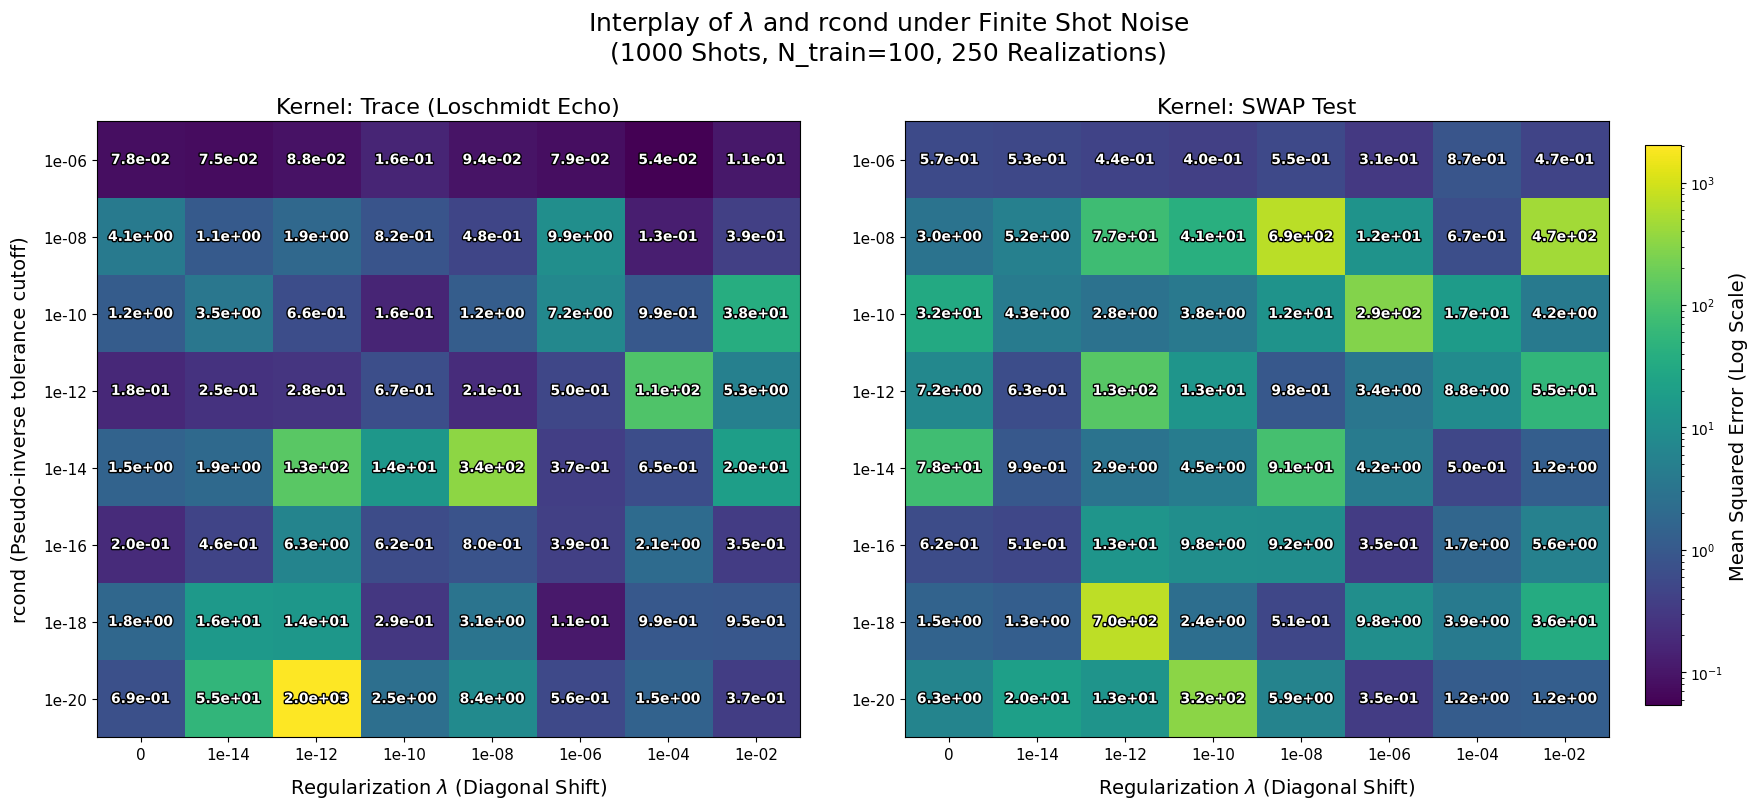

In [23]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as patheffects
# import myQML 

# --- Settings ---
N_train = 100
N_test = 200
num_realizations = 250
num_shots = 1000  # <--- Now set to 1000 shots

rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]
lambda_list = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

# Storage for the MSE values
mse_grid_trace = np.zeros((len(rcond_list), len(lambda_list), num_realizations))
mse_grid_swap = np.zeros((len(rcond_list), len(lambda_list), num_realizations))

print(f"Starting {num_realizations} realizations (N_train={N_train}, shots={num_shots})...")
total_time = time.time()

# --- Main Evaluation Loop ---
for r in range(num_realizations):
    if (r + 1) % 25 == 0:
        print(f"  -> Processed {r + 1}/{num_realizations} datasets...")
        
    # 1. Generate Dataset ONCE per realization
    ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()
    
    rho_train, y_train = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()
    
    # 2. Test all parameter combinations on this dataset
    for i, rcond in enumerate(rcond_list):
        for j, reg_lambda in enumerate(lambda_list):
            
            # --- TRACE (Loschmidt Echo) ---
            model_trace = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, num_shots=num_shots, r_cond=rcond)
            model_trace.fit_vec(rho_train, y_train, "trace")
            y_pred_trace = model_trace.predict_vec(rho_test)
            mse_grid_trace[i, j, r] = np.mean((y_pred_trace - y_test)**2)
            
            # --- SWAP Test ---
            model_swap = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, num_shots=num_shots, r_cond=rcond)
            model_swap.fit_vec(rho_train, y_train, "swap")
            y_pred_swap = model_swap.predict_vec(rho_test)
            mse_grid_swap[i, j, r] = np.mean((y_pred_swap - y_test)**2)

print(f"Computations finished in {(time.time() - total_time)/60:.1f} minutes.")

# --- Calculate Mean MSE across all realizations ---
mean_mse_trace = np.mean(mse_grid_trace, axis=2)
mean_mse_swap = np.mean(mse_grid_swap, axis=2)

# --- Plotting the Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Find global min and max so both plots share the exact same color scale
# This is crucial so you can visually compare which kernel is performing better
vmin_global = min(np.min(mean_mse_trace), np.min(mean_mse_swap))
vmax_global = max(np.max(mean_mse_trace), np.max(mean_mse_swap))
norm = mcolors.LogNorm(vmin=vmin_global, vmax=vmax_global)

titles = [
    f'Kernel: Trace (Loschmidt Echo)',
    f'Kernel: SWAP Test'
]
grids = [mean_mse_trace, mean_mse_swap]

for ax, grid, title in zip(axes, grids, titles):
    cax = ax.imshow(grid, cmap='viridis', norm=norm, aspect='auto')
    
    ax.set_xticks(np.arange(len(lambda_list)))
    ax.set_yticks(np.arange(len(rcond_list)))
    
    ax.set_xticklabels([f"{l:.0e}" if l > 0 else "0" for l in lambda_list], fontsize=11)
    ax.set_yticklabels([f"{r:.0e}" for r in rcond_list], fontsize=11)
    
    ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
    if ax == axes[0]:
        ax.set_ylabel('rcond (Pseudo-inverse tolerance cutoff)', fontsize=14, labelpad=10)
    
    ax.set_title(title, fontsize=16)
    
    # Annotate each cell
    for i in range(len(rcond_list)):
        for j in range(len(lambda_list)):
            val = grid[i, j]
            ax.text(j, i, f"{val:.1e}", ha="center", va="center", color="white", 
                    fontsize=10, fontweight='bold',
                    path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

# Add a single shared colorbar for both plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cax, cax=cbar_ax)
cbar.set_label('Mean Squared Error (Log Scale)', fontsize=14)

plt.subplots_adjust(left=0.06, right=0.9, wspace=0.15)
fig.suptitle(f'Interplay of $\lambda$ and rcond under Finite Shot Noise\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=18, y=1.02)
plt.show()

<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/760013673.py:85: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_91420/760013673.py:105: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Interplay of $\lambda$ and rcond under Finite Shot Noise\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=18, y=1.02)


Starting 250 realizations (N_train=100, shots=100)...
  -> Processed 25/250 datasets...
  -> Processed 50/250 datasets...
  -> Processed 75/250 datasets...
  -> Processed 100/250 datasets...
  -> Processed 125/250 datasets...
  -> Processed 150/250 datasets...
  -> Processed 175/250 datasets...
  -> Processed 200/250 datasets...
  -> Processed 225/250 datasets...
  -> Processed 250/250 datasets...
Computations finished in 8.2 minutes.


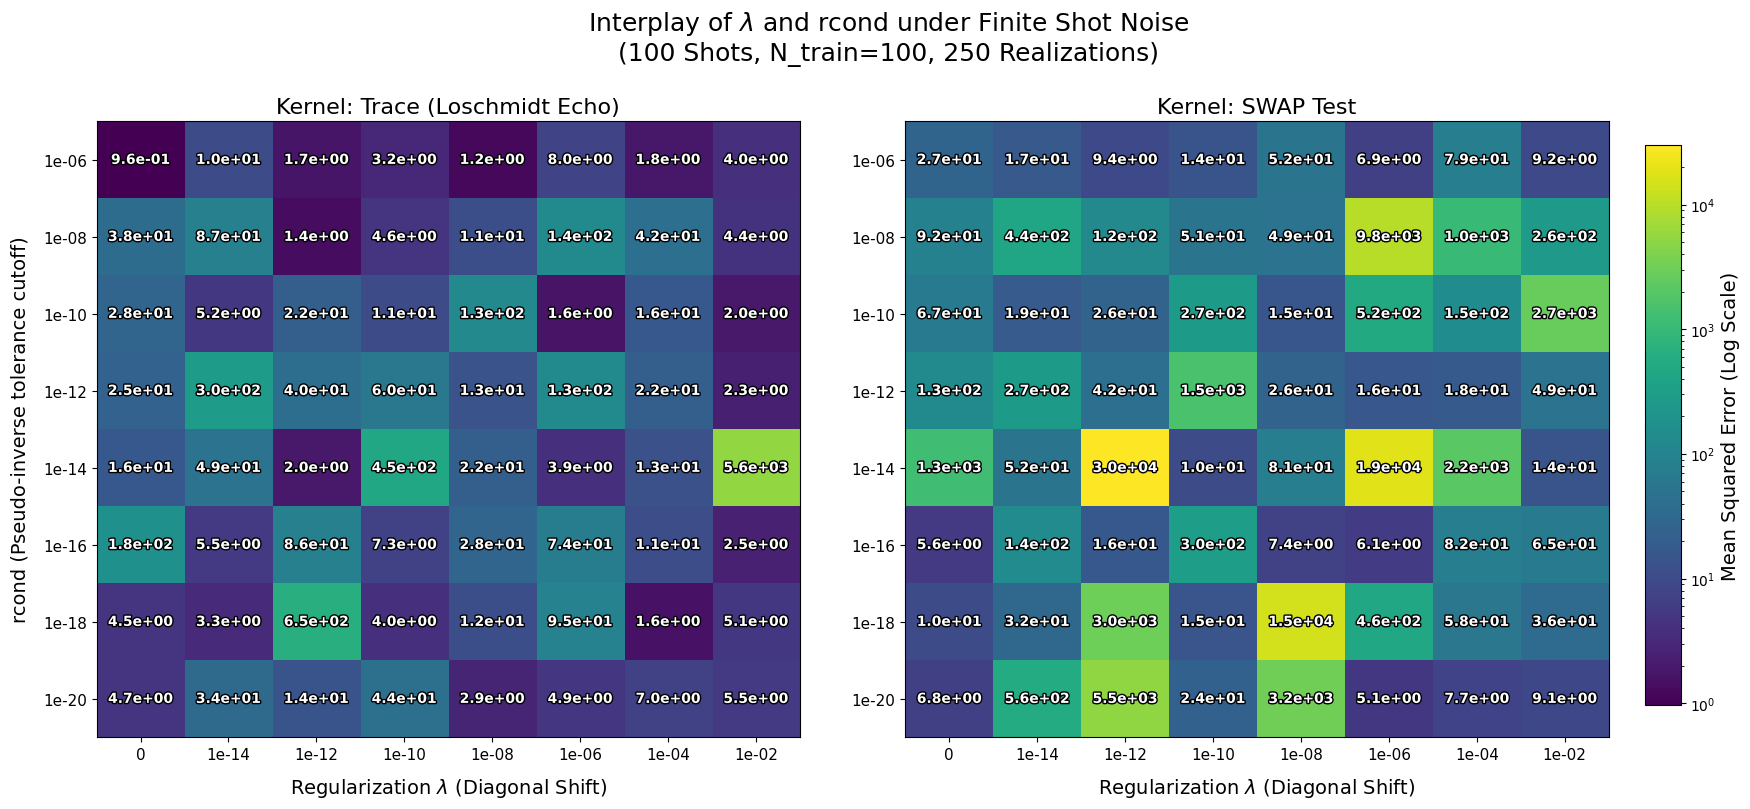

In [24]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as patheffects
# import myQML 

# --- Settings ---
N_train = 100
N_test = 200
num_realizations = 250
num_shots = 100  # <--- Now set to 100 shots

rcond_list = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18, 1e-20]
lambda_list = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

# Storage for the MSE values
mse_grid_trace = np.zeros((len(rcond_list), len(lambda_list), num_realizations))
mse_grid_swap = np.zeros((len(rcond_list), len(lambda_list), num_realizations))

print(f"Starting {num_realizations} realizations (N_train={N_train}, shots={num_shots})...")
total_time = time.time()

# --- Main Evaluation Loop ---
for r in range(num_realizations):
    if (r + 1) % 25 == 0:
        print(f"  -> Processed {r + 1}/{num_realizations} datasets...")
        
    # 1. Generate Dataset ONCE per realization
    ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()
    
    rho_train, y_train = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()
    
    # 2. Test all parameter combinations on this dataset
    for i, rcond in enumerate(rcond_list):
        for j, reg_lambda in enumerate(lambda_list):
            
            # --- TRACE (Loschmidt Echo) ---
            model_trace = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, num_shots=num_shots, r_cond=rcond)
            model_trace.fit_vec(rho_train, y_train, "trace")
            y_pred_trace = model_trace.predict_vec(rho_test)
            mse_grid_trace[i, j, r] = np.mean((y_pred_trace - y_test)**2)
            
            # --- SWAP Test ---
            model_swap = myQML.QuantumKernelRegression(
                regularization_lambda=reg_lambda, num_shots=num_shots, r_cond=rcond)
            model_swap.fit_vec(rho_train, y_train, "swap")
            y_pred_swap = model_swap.predict_vec(rho_test)
            mse_grid_swap[i, j, r] = np.mean((y_pred_swap - y_test)**2)

print(f"Computations finished in {(time.time() - total_time)/60:.1f} minutes.")

# --- Calculate Mean MSE across all realizations ---
mean_mse_trace = np.mean(mse_grid_trace, axis=2)
mean_mse_swap = np.mean(mse_grid_swap, axis=2)

# --- Plotting the Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Find global min and max so both plots share the exact same color scale
# This is crucial so you can visually compare which kernel is performing better
vmin_global = min(np.min(mean_mse_trace), np.min(mean_mse_swap))
vmax_global = max(np.max(mean_mse_trace), np.max(mean_mse_swap))
norm = mcolors.LogNorm(vmin=vmin_global, vmax=vmax_global)

titles = [
    f'Kernel: Trace (Loschmidt Echo)',
    f'Kernel: SWAP Test'
]
grids = [mean_mse_trace, mean_mse_swap]

for ax, grid, title in zip(axes, grids, titles):
    cax = ax.imshow(grid, cmap='viridis', norm=norm, aspect='auto')
    
    ax.set_xticks(np.arange(len(lambda_list)))
    ax.set_yticks(np.arange(len(rcond_list)))
    
    ax.set_xticklabels([f"{l:.0e}" if l > 0 else "0" for l in lambda_list], fontsize=11)
    ax.set_yticklabels([f"{r:.0e}" for r in rcond_list], fontsize=11)
    
    ax.set_xlabel('Regularization $\lambda$ (Diagonal Shift)', fontsize=14, labelpad=10)
    if ax == axes[0]:
        ax.set_ylabel('rcond (Pseudo-inverse tolerance cutoff)', fontsize=14, labelpad=10)
    
    ax.set_title(title, fontsize=16)
    
    # Annotate each cell
    for i in range(len(rcond_list)):
        for j in range(len(lambda_list)):
            val = grid[i, j]
            ax.text(j, i, f"{val:.1e}", ha="center", va="center", color="white", 
                    fontsize=10, fontweight='bold',
                    path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

# Add a single shared colorbar for both plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cax, cax=cbar_ax)
cbar.set_label('Mean Squared Error (Log Scale)', fontsize=14)

plt.subplots_adjust(left=0.06, right=0.9, wspace=0.15)
fig.suptitle(f'Interplay of $\lambda$ and rcond under Finite Shot Noise\n({num_shots} Shots, N_train={N_train}, {num_realizations} Realizations)', fontsize=18, y=1.02)
plt.show()

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML

####### Helper Function #########
def get_n_qubit_observable(n, base_op):
    """
    Generates an n-qubit observable by taking the tensor product 
    of the base_op n times. E.g., for base_op = X, returns X^otimes n.
    """
    obs = base_op
    for _ in range(n - 1):
        obs = np.kron(obs, base_op)
    return obs

####### Settings #########
n_qubits_list = [1, 2, 3] # The number of qubits (n)
N_train = 100                
N_test = 200                 
num_realizations = 30
num_shots = 0

# CRITICAL: Since num_shots=1000, we MUST use regularization to prevent matrix inversion explosion!
reg_lambda = 0 

# QELM reservoir physical setup (Fixed part)
d_res = 64
num_povm_elements = 20

# Generate POVM ONCE since it only depends on the fixed d_res
povm = myQML.generate_random_povm(d_res, num_povm_elements)

# Storage dictionaries (Updated for quantiles)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Fixed N_train = {N_train}, Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for n in n_qubits_list:
    d_in = 2**n              
    d_out = d_in * d_res     
    
    print(f"Evaluating n = {n} qubits (d_in = {d_in})...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    obs_n = get_n_qubit_observable(n, myQML.X)

    for r in range(num_realizations):
        # Using vectorization for massive speedup
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, obs_n)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()
        
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_out)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Mean, Median, 5% and 95% Quantiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Plotting
# ==========================================
plt.figure(figsize=(11, 7))
n_arr = np.array(n_qubits_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': f'QELM ($d_{{res}}={d_res}$, $n_{{povm}}={num_povm_elements}$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median (Solid)
    plt.plot(n_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Plot Mean (Dashed, Empty marker)
    plt.plot(n_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # Fill between 5% and 95% quantiles
    plt.fill_between(n_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15)

plt.xticks(n_qubits_list) 
plt.yscale('log') 

plt.xlabel('Number of Qubits ($n$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Scaling with System Size: QELM vs Quantum Kernels\n(Fixed $N_{{train}} = {N_train}$, {num_shots} Shots)', fontsize=16)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()

-------- (Fixed N_train = 100, Shots = 0, Realizations = 30) --------
Evaluating n = 1 qubits (d_in = 2)...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     14.3s
Evaluating n = 2 qubits (d_in = 4)...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     64.1s
Evaluating n = 3 qubits (d_in = 8)...


In [27]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML

####### Helper Function #########
def get_n_qubit_observable(n, base_op):
    """
    Generates an n-qubit observable by taking the tensor product 
    of the base_op n times. E.g., for base_op = X, returns X^otimes n.
    """
    obs = base_op
    for _ in range(n - 1):
        obs = np.kron(obs, base_op)
    return obs

####### Settings #########
n_qubits_list = [1, 2, 3] # The number of qubits (n)
N_train = 100                
N_test = 200                 
num_realizations = 30
num_shots = 1000

# CRITICAL: Since num_shots=1000, we MUST use regularization to prevent matrix inversion explosion!
reg_lambda = 0 

# QELM reservoir physical setup (Fixed part)
d_res = 64
num_povm_elements = 20

# Generate POVM ONCE since it only depends on the fixed d_res
povm = myQML.generate_random_povm(d_res, num_povm_elements)

# Storage dictionaries (Updated for quantiles)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Fixed N_train = {N_train}, Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for n in n_qubits_list:
    d_in = 2**n              
    d_out = d_in * d_res     
    
    print(f"Evaluating n = {n} qubits (d_in = {d_in})...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    obs_n = get_n_qubit_observable(n, myQML.X)

    for r in range(num_realizations):
        # Using vectorization for massive speedup
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, obs_n)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()
        
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_out)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Mean, Median, 5% and 95% Quantiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Plotting
# ==========================================
plt.figure(figsize=(11, 7))
n_arr = np.array(n_qubits_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': f'QELM ($d_{{res}}={d_res}$, $n_{{povm}}={num_povm_elements}$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median (Solid)
    plt.plot(n_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Plot Mean (Dashed, Empty marker)
    plt.plot(n_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # Fill between 5% and 95% quantiles
    plt.fill_between(n_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15)

plt.xticks(n_qubits_list) 
plt.yscale('log') 

plt.xlabel('Number of Qubits ($n$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Scaling with System Size: QELM vs Quantum Kernels\n(Fixed $N_{{train}} = {N_train}$, {num_shots} Shots)', fontsize=16)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()

-------- (Fixed N_train = 100, Shots = 1000, Realizations = 30) --------
Evaluating n = 1 qubits (d_in = 2)...


  -> QELM MSE: 0.1443
  -> K-LE MSE: 2.7462
  -> K-SW MSE: 10.8334
  -> Time:     15.2s
Evaluating n = 2 qubits (d_in = 4)...
  -> QELM MSE: 0.0657
  -> K-LE MSE: 2.6278
  -> K-SW MSE: 1495.4170
  -> Time:     65.4s
Evaluating n = 3 qubits (d_in = 8)...


KeyboardInterrupt: 